In [1]:
import os
import yaml
import pandas as pd
from pathlib import Path


def _flatten(d: dict, prefix: str = "") -> dict:
    """Recursively flatten a nested dict with dot-separated keys."""
    out = {}
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else k
        print(type(v), key, v)
        if isinstance(v, dict):
            out.update(_flatten(v, key))
        elif isinstance(v, list):
            for i, item in enumerate(v):
                item_key = f"{key}[{i}]"
                if isinstance(item, dict):
                    out.update(_flatten(item, item_key))
                else:
                    out[item_key] = item
        else:
            out[key] = v
    return out


def collect_runs(root: str | os.PathLike) -> pd.DataFrame:
    """
    Walk *root* and return a DataFrame where each row is one run.

    A "run" is any directory that contains a ``params.yaml`` file.

    Columns
    -------
    run_path       : absolute path of the run directory
    <param keys>   : flattened params.yaml entries  (dot-separated for nested keys)
    <metric keys>  : columns from metrics_summary.csv prefixed as metric.class
                     (e.g. ``AP50.all``, ``F1.car``)
    files          : list[str] of filenames present directly in the run directory
    """
    rows = []

    for dirpath, dirnames, filenames in os.walk(root):
        if "params.yaml" not in filenames:
            continue

        run_dir = Path(dirpath)
        row: dict = {"run_path": str(run_dir)}

        # --- params ---
        with open(run_dir / "params.yaml") as f:
            params = yaml.safe_load(f) or {}
        row.update(_flatten(params))

        # --- metrics ---
        metrics_file = run_dir / "metrics_summary.json"

        if metrics_file.exists():
            # Flatten json with dot-separated keys, and prefix with "metric."
            with open(metrics_file) as f:
                metrics = yaml.safe_load(f) or {}
            metrics_flat = _flatten(metrics, prefix="metric")
            row.update(metrics_flat)
        # --- files ---
        row["files"] = sorted(filenames)

        rows.append(row)

    return pd.DataFrame(rows)


In [2]:
OUT_DIR = "../out/cineca"

res_df = collect_runs(OUT_DIR)
res_df

<class 'list'> classes ['crashed_car', 'person', 'car']
<class 'dict'> model {'model': 'yolo11m', 'name': 'yolo'}
<class 'str'> model.model yolo11m
<class 'str'> model.name yolo
<class 'dict'> train {'data': 'data/VistaSynth/data.yaml'}
<class 'str'> train.data data/VistaSynth/data.yaml
<class 'dict'> val {'data': 'data/VistaSynth/data.yaml', 'split': 'test'}
<class 'str'> val.data data/VistaSynth/data.yaml
<class 'str'> val.split test
<class 'dict'> metric.summary {'P': 0.7392102603797804, 'R': 0.784671784212918, 'mAP50': 0.7981095169341815, 'mAP50-95': 0.41102938184742666, 'fitness': 0.41102938184742666}
<class 'float'> metric.summary.P 0.7392102603797804
<class 'float'> metric.summary.R 0.784671784212918
<class 'float'> metric.summary.mAP50 0.7981095169341815
<class 'float'> metric.summary.mAP50-95 0.41102938184742666
<class 'float'> metric.summary.fitness 0.41102938184742666
<class 'dict'> metric.speed {'preprocess_ms_per_image': 1.598, 'inference_ms_per_image': 2.888, 'loss_ms_per

,run_path,classes[0],classes[1],classes[2],model.model,model.name,train.data,val.data,val.split,metric.summary.P,...,metric.per_class.car.mAP50-95,files,metric.per_class.crashed_car.Images,metric.per_class.crashed_car.Instances,metric.per_class.crashed_car.Box-P,metric.per_class.crashed_car.Box-R,metric.per_class.crashed_car.Box-F1,metric.per_class.crashed_car.mAP50,metric.per_class.crashed_car.mAP50-95,model.model_id
0,../out/cineca/2026-04-18_12-07-04_Train/run_7,crashed_car,person,car,yolo11m,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.739210,...,0.45548,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,../out/cineca/2026-04-18_12-07-04_Train/run_5,crashed_car,person,car,yolo12x,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.830548,...,0.46011,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,../out/cineca/2026-04-18_12-07-04_Train/run_3,crashed_car,person,car,yolo12n,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.708721,...,0.42594,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,../out/cineca/2026-04-18_12-07-04_Train/run_0,crashed_car,person,car,yolo26n,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.596653,...,0.40779,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,../out/cineca/2026-04-18_12-07-04_Train/run_8,crashed_car,person,car,yolo11x,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.771072,...,0.46477,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,../out/cineca/2026-04-18_12-07-04_Train/run_6,crashed_car,person,car,yolo11n,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.709915,...,0.39205,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,../out/cineca/2026-04-18_12-07-04_Train/run_4,crashed_car,person,car,yolo12m,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.825206,...,0.45042,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,../out/cineca/2026-04-18_12-07-04_Train/run_1,crashed_car,person,car,yolo26m,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.755665,...,0.43496,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,../out/cineca/2026-04-18_12-07-04_Train/run_2,crashed_car,person,car,yolo26x,yolo,data/VistaSynth/data.yaml,data/VistaSynth/data.yaml,test,0.836791,...,0.45889,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,../out/cineca/2026-04-18_17-53-05_Base/run_0,crashed_car,person,car,yoloe-26s-seg.pt,yoloe,NaN,data/VistaSynth/data.yaml,test,0.374823,...,0.11633,"[BoxF1_curve.png, BoxPR_curve.png, BoxP_curve....",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = res_df.copy()

df["model"] = df[["model.name", "model.model_id", "model.model"]].apply(
    lambda r: " / ".join(str(v) for v in r if pd.notna(v)), axis=1
)

columns = ["model", 'metric.speed.fps_inference',  'metric.summary.mAP50', 'metric.summary.mAP50-95', 'metric.per_class.car.mAP50', 'metric.per_class.crashed_car.mAP50', 'metric.per_class.person.mAP50']

# Some rows have "crashed car" instead of "crashed_car" due to a bug in the code that generates the metrics. We want to include both columns if they exist, and ignore missing ones.

# assert at least one contains a value
assert df[["metric.per_class.crashed_car.mAP50", "metric.per_class.crashed car.mAP50"]].notna().any().any(), "Neither 'crashed_car' nor 'crashed car' columns contain any values"
# assert not both contain values in the same row (should be mutually exclusive)
assert not (df["metric.per_class.crashed_car.mAP50"].notna() & df["metric.per_class.crashed car.mAP50"].notna()).any(), "Some rows contain values in both 'crashed_car' and 'crashed car' columns, which should be mutually exclusive"
# fill missing values in one column with the other
df["metric.per_class.crashed_car.mAP50"] = df["metric.per_class.crashed_car.mAP50"].combine_first(df["metric.per_class.crashed car.mAP50"])

# multiply map columns by 100 to convert to percentage and round to 2 decimal places
map_columns = [col for col in df.columns if col.startswith("metric.summary.mAP") or col.startswith("metric.per_class.")]
df[map_columns] = df[map_columns] * 100
df[map_columns] = df[map_columns].round(2)


df[columns]

,model,metric.speed.fps_inference,metric.summary.mAP50,metric.summary.mAP50-95,metric.per_class.car.mAP50,metric.per_class.crashed_car.mAP50,metric.per_class.person.mAP50
0,yolo / yolo11m,346.3,79.81,41.10,76.94,88.05,74.44
1,yolo / yolo12x,143.0,80.95,41.36,76.79,89.72,76.35
2,yolo / yolo12n,395.9,64.89,34.82,72.95,88.38,33.34
3,yolo / yolo26n,440.5,64.98,33.66,70.50,86.68,37.76
4,yolo / yolo11x,212.6,76.82,41.06,77.89,88.43,64.15
5,yolo / yolo11n,534.8,65.67,33.50,69.05,86.56,41.39
6,yolo / yolo12m,258.4,76.92,39.46,74.39,86.68,69.68
7,yolo / yolo26m,276.4,74.71,37.49,73.64,89.28,61.21
8,yolo / yolo26x,186.1,80.27,42.35,75.90,89.53,75.39
9,yoloe / yoloe-26s-seg.pt,294.6,40.77,14.86,30.38,41.61,50.32


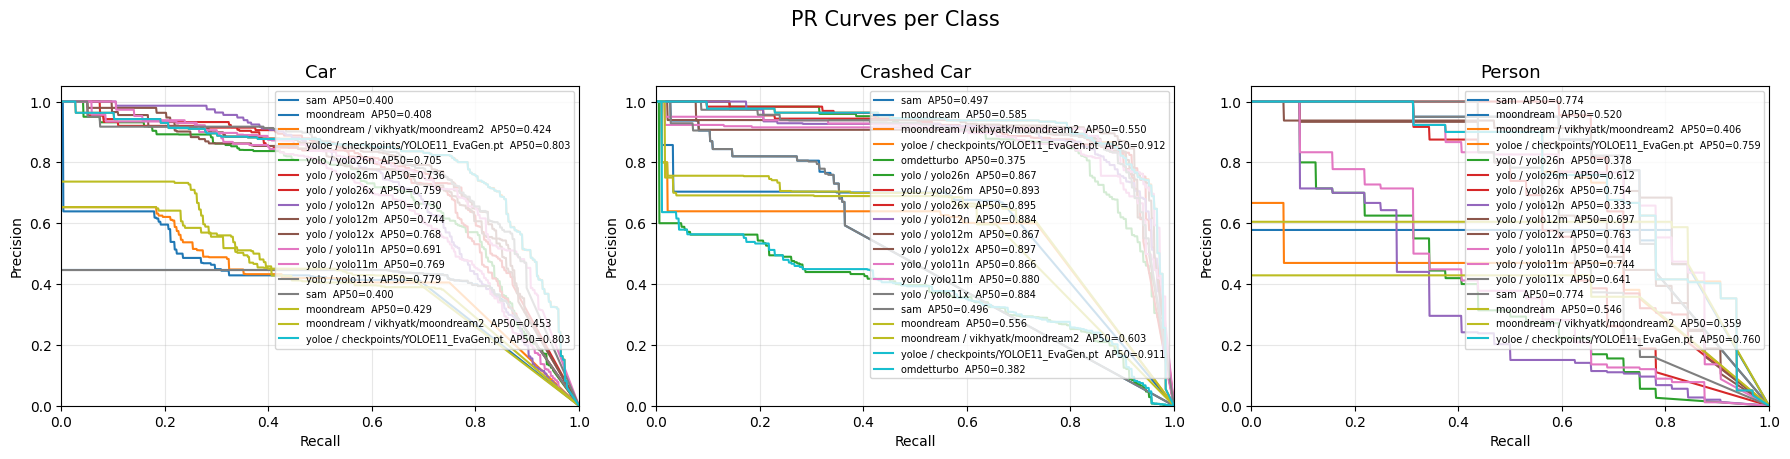

In [25]:
import json
import yaml
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

OUT_DIR = Path("../out")

# ── collect all runs that have a pr_curves.json ───────────────────────────────
runs = []
for pr_path in sorted(OUT_DIR.rglob("pr_curves.json")):
    run_dir = pr_path.parent
    params_file = run_dir / "params.yaml"
    if not params_file.exists():
        continue

    with open(params_file) as f:
        params = yaml.safe_load(f) or {}

    model_info  = params.get("model", {})
    model_name  = model_info.get("name", run_dir.name)
    model_id    = model_info.get("model_id") or None
    model_model = model_info.get("model") or None

    parts = [model_name] + [p for p in [model_id, model_model] if p]
    label = " / ".join(parts)

    with open(pr_path) as f:
        pr_data = json.load(f)

    runs.append({
        "label":    label,
        "recall":   np.array(pr_data["recall"]),
        "per_class": {
            # normalise class names: strip spaces → underscores
            cls.replace(" ", "_"): {
                "precision": np.array(info["precision"]),
                "ap50":      info.get("ap50"),
            }
            for cls, info in pr_data["per_class"].items()
        },
    })

# ── gather all unique class names across every run ────────────────────────────
all_classes = sorted({cls for run in runs for cls in run["per_class"]})

# ── one subplot per class ─────────────────────────────────────────────────────
ncols = min(3, len(all_classes))
nrows = (len(all_classes) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)

colors = cm.tab10(np.linspace(0, 1, len(runs)))

for ax, cls_name in zip(axes.flat, all_classes):
    for run, color in zip(runs, colors):
        if cls_name not in run["per_class"]:
            continue
        info   = run["per_class"][cls_name]
        ap_str = f"  AP50={info['ap50']:.3f}" if info["ap50"] is not None else ""
        ax.plot(run["recall"], info["precision"],
                label=f"{run['label']}{ap_str}", color=color, linewidth=1.5)

    ax.set_title(cls_name.replace("_", " ").title(), fontsize=13)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

# hide unused axes
for ax in axes.flat[len(all_classes):]:
    ax.set_visible(False)

fig.suptitle("PR Curves per Class", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()
